# 1. Tổng quan dataset

### 1.1 Kiểm tra số lượng ảnh trong images và masks

In [24]:

from pathlib import Path
import numpy as np
from PIL import Image
import cv2


DATA_PATH = Path("/Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/test/test_img")
DATA_PATH_2 = Path("/Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/test/test_seg_label")

len_imgs = len(list(DATA_PATH.glob("*.*")))

print(f"Số lượng ảnh trong dataset: {len_imgs}")

Số lượng ảnh trong dataset: 13391


In [11]:
len_imgs = len(list(DATA_PATH.glob("*.*")))

print(f"Số lượng ảnh trong dataset: {len_imgs}")

Số lượng ảnh trong dataset: 13391


### 1.2 kiểm tra mask có hợp lệ

In [12]:

def mask_area(mask_path):
    mask = np.array(Image.open(mask_path).convert("L"))
    return np.sum(mask > 0)

areas = []
for mask in DATA_PATH.glob("*.*"):
    areas.append(mask_area(mask))

areas = np.array(areas)

print(f"mask rỗng: {np.sum(areas == 0)}")
print(f"mask có diện tích: {np.sum(areas > 0)}")

mask rỗng: 0
mask có diện tích: 13391


### 1.3 Kiểm tra vùng mask chiếm bao nhiêu phần trăm ảnh

In [15]:
ratios = []
for img_path, mask_path in zip(DATA_PATH.glob("*.*"), DATA_PATH_2.glob("*.*")):
    img = Image.open(img_path)
    mask = Image.open(mask_path).convert("L")

    h, w = img.size
    mask_area = np.sum(np.array(mask) > 0)
    ratio = mask_area / (h * w)
    ratios.append(ratio)

print(f"Tỷ lệ trung bình: {np.mean(ratios)}")

Tỷ lệ trung bình: 0.03365844049710831


In [16]:
import pandas as pd
df = pd.DataFrame({
    "image": [p.name for p in DATA_PATH.glob("*.*")],
    "mask_ratio": ratios
})
df.describe()

,mask_ratio
count,13391.000000
mean,0.033658
std,0.026935
min,0.001862
25%,0.014328
50%,0.024864
75%,0.044394
max,0.256287


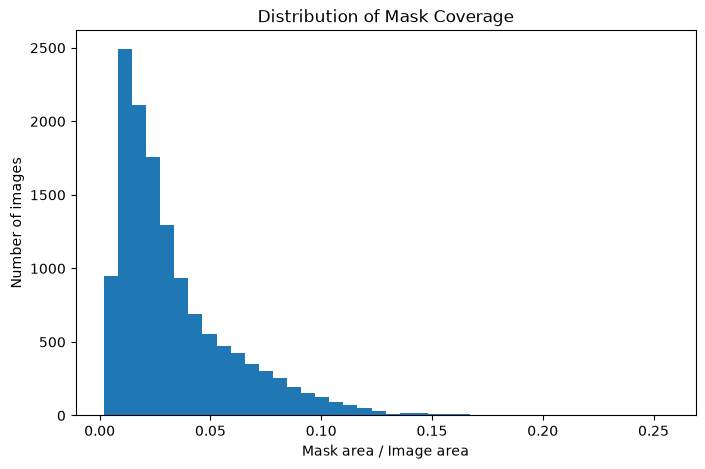

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["mask_ratio"], bins=40)
plt.xlabel("Mask area / Image area")
plt.ylabel("Number of images")
plt.title("Distribution of Mask Coverage")
plt.show()

# 1.4 Kiểm tra format của dataset

In [18]:
from collections import Counter
from PIL import Image
format_counter = Counter()

for img_path in DATA_PATH.glob("*.*"):
    try:
        with Image.open(img_path) as img:
            format_counter[img.format] += 1
    except Exception as e:
        print(f"Error opening image {img_path}: {e}")

print("Thống kê format thực tế của các file:")
for fmt, count in format_counter.items():
    print(f"- {fmt}: {count} file")

Thống kê format thực tế của các file:
- JPEG: 13391 file


# 1.5 Kiểm tra ảnh có trùng lặp

In [19]:
import hashlib
from collections import defaultdict

hash_dict = defaultdict(list)
for img_path in DATA_PATH.glob("*.*"):
    with open(img_path, "rb") as f:
        file_hash = hashlib.md5(f.read()).hexdigest()
        hash_dict[file_hash].append(img_path.name)

duplicates = {h: files for h, files in hash_dict.items() if len(files) > 1}

if duplicates:
    print("Phát hiện các file trùng lặp chính xác:")
    for h, files in duplicates.items():
        print(f"- Nhóm trùng ({h}): {files}")
else:
    print("Không tìm thấy file nào trùng lặp chính xác.")

Không tìm thấy file nào trùng lặp chính xác.


# 1.6 Visualize một số ảnh và mask

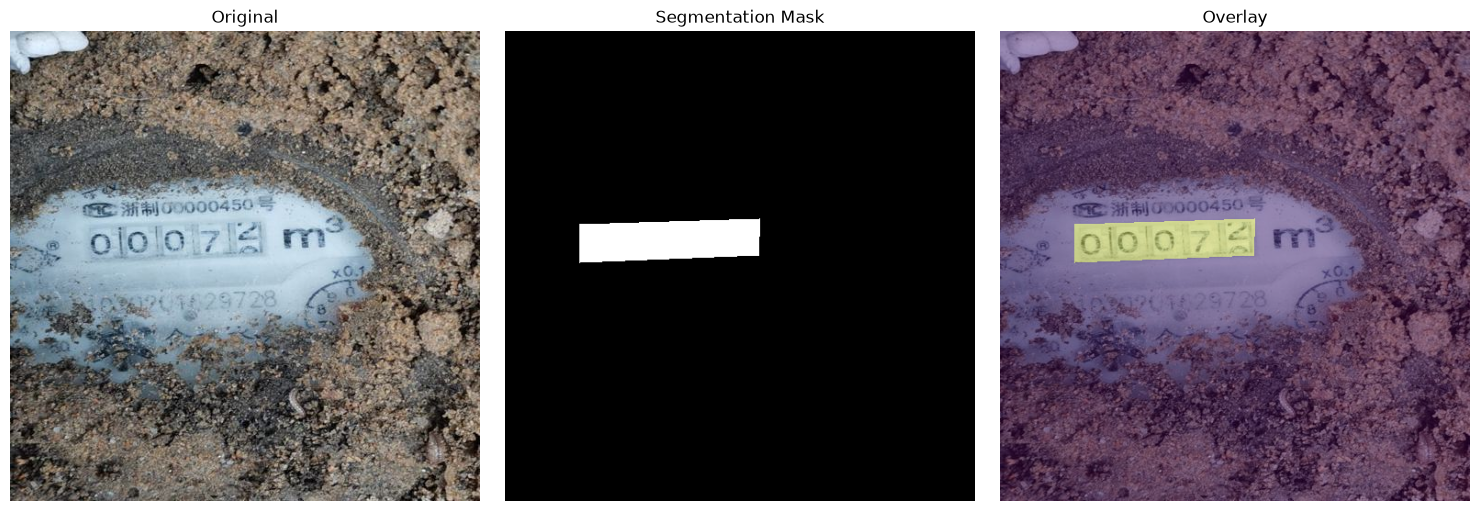

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

idx = 0

img_files = list(DATA_PATH.glob("*.*"))
img = np.array(Image.open(img_files[idx]).convert("RGB"))

mask_files = list(DATA_PATH_2.glob("*.*"))
mask = np.array(Image.open(mask_files[idx]).convert("L"))


fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img)
axes[0].set_title("Original")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Segmentation Mask")

axes[2].imshow(img)
axes[2].imshow(mask, alpha=0.4)
axes[2].set_title("Overlay")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

### 1.7 Vẽ heatmap để xem vùng mask tập trung ở đâu nhiều nhất

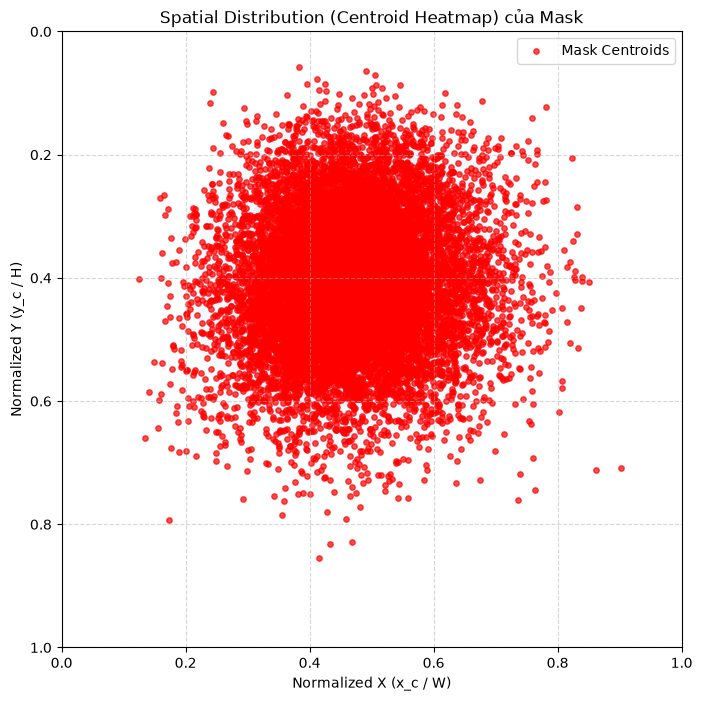

In [21]:
import seaborn as sns
normalized_centroids = []

for mask_path in mask_files:
    try:
        # Đọc ảnh mask về dạng mảng nhị phân hoặc xám
        mask = np.array(Image.open(mask_path).convert("L"))
        
        # Lấy kích thước ảnh (Height, Width)
        H, W = mask.shape
        
        # Tìm tọa độ các pixel thuộc đối tượng (khác 0)
        y_indices, x_indices = np.where(mask > 0)
        
        if len(x_indices) == 0 or len(y_indices) == 0:
            continue  # Bỏ qua nếu mask trống
            
        # Tính centroid (tâm hình học)
        xc = np.mean(x_indices)
        yc = np.mean(y_indices)
        
        # Chuẩn hóa về khoảng [0, 1] theo chiều rộng (W) và chiều cao (H)
        xc_norm = xc / W
        yc_norm = yc / H
        
        normalized_centroids.append((xc_norm, yc_norm))
        
    except Exception as e:
        print(f"Lỗi đọc file {mask_path.name}: {e}")

# Chuyển sang NumPy array để xử lý
normalized_centroids = np.array(normalized_centroids)
x_coords = normalized_centroids[:, 0]
y_coords = normalized_centroids[:, 1]

# 2. Vẽ biểu đồ Scatter kết hợp Heatmap phân bố không gian
plt.figure(figsize=(8, 8))

# Tạo Heatmap mờ phía sau bằng KDE plot
sns.kdeplot(
    x=x_coords,
    y=y_coords,
    cmap="Blues",
    fill=True,
    thresh=0.05,
    levels=10,
    alpha=0.6,
)

plt.scatter(
    x_coords, y_coords, color="red", s=15, alpha=0.7, label="Mask Centroids"
)

plt.gca().invert_yaxis()

plt.xlim(0, 1)
plt.ylim(1, 0)  # Đảo ngược trục Y chuẩn ảnh
plt.xlabel("Normalized X (x_c / W)")
plt.ylabel("Normalized Y (y_c / H)")
plt.title("Spatial Distribution (Centroid Heatmap) của Mask")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### 1.8 Kiểm tra lỗi segmentation

In [25]:
errors = {
    "too_small": [],  # Mask area < 0.1%
    "too_large": [],  # Mask area > 90%
    "touch_boundary": [],  # Mask chạm biên ảnh
    "multi_components": [],  # Có nhiều vùng rời rạc (Connected Components > 1)
}

for mask_path in DATA_PATH_2.glob("*.*"):
    try:
        # Đọc ảnh mask sang dạng mảng xám
        mask = np.array(Image.open(mask_path).convert("L"))
        H, W = mask.shape
        
        # Chuyển về dạng nhị phân (0 và 255 hoặc 0 và 1)
        _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
        
        # Tổng số pixel của ảnh
        total_pixels = H * W
        if total_pixels == 0:
            continue
            
        # Đếm số pixel thuộc đối tượng (giá trị 255)
        mask_pixels = np.sum(binary_mask == 255)
        area_ratio = mask_pixels / total_pixels
        
        # --- Kiểm tra lỗi 1: Mask quá nhỏ (< 0.1%) ---
        if area_ratio < 0.001:
            errors["too_small"].append((mask_path.name, area_ratio * 100))
            
        # --- Kiểm tra lỗi 2: Mask quá lớn (> 90%) ---
        if area_ratio > 0.90:
            errors["too_large"].append((mask_path.name, area_ratio * 100))
            
        # --- Kiểm tra lỗi 3: Mask chạm biên ---
        # Tìm tọa độ các điểm thuộc mask
        y_indices, x_indices = np.where(binary_mask == 255)
        
        if len(x_indices) > 0 and len(y_indices) > 0:
            x_min, x_max = np.min(x_indices), np.max(x_indices)
            y_min, y_max = np.min(y_indices), np.max(y_indices)
            
            # Kiểm tra xem biên của bounding box có chạm sát viền ảnh không
            if x_min == 0 or y_min == 0 or x_max >= W - 1 or y_max >= H - 1:
                errors["touch_boundary"].append(mask_path.name)
                
        # --- Kiểm tra lỗi 4: Nhiều connected components (vùng rời rạc) ---
        # Dùng cv2.connectedComponents để đếm số vùng độc lập của đối tượng
        num_labels, labels = cv2.connectedComponents(binary_mask)
        # num_labels bao gồm cả background (label 0), nên số vùng thực tế là num_labels - 1
        num_objects = num_labels - 1
        
        if num_objects > 1:
            errors["multi_components"].append((mask_path.name, num_objects))
            
    except Exception as e:
        print(f"Lỗi xử lý file {mask_path.name}: {e}")

# In kết quả báo cáo tổng kết
print(f"- Tổng số mask quá nhỏ (< 0.1%): {len(errors['too_small'])}")
print(f"- Tổng số mask quá lớn (> 90%): {len(errors['too_large'])}")
print(f"- Tổng số mask chạm biên: {len(errors['touch_boundary'])}")
print(f"- Tổng số mask có nhiều vùng rời rạc (>1): {len(errors['multi_components'])}")

# Ví dụ hiển thị chi tiết một vài lỗi (nếu có)
if errors["multi_components"]:
    print("\nChi tiết các file có nhiều connected components:")
    for name, count in errors["multi_components"][:5]:
        print(f"  + File: {name} (Có {count} vùng)")

- Tổng số mask quá nhỏ (< 0.1%): 0
- Tổng số mask quá lớn (> 90%): 0
- Tổng số mask chạm biên: 128
- Tổng số mask có nhiều vùng rời rạc (>1): 0


# 2. Kiểm tra file csv

In [26]:

csv_path = Path("/Users/mac/MeterReadAI/data/Word-Wheel_Water_Meter_Dataset/detection/test/test_class_label_CSV.csv")

df_csv = pd.read_csv(csv_path)

print(df_csv.shape)

(13390, 8)


In [27]:
print(df_csv.head())

   test0.png  0  0.1  1  0.2  0.3  0.4  0.5
0  test1.png  0    0  1    0    0    0    1
1  test2.png  0    0  1    0    0    0    1
2  test3.png  0    0  1    0    0    0    1
3  test4.png  0    0  1    0    0    0    1
4  test5.png  0    0  1    0    0    0    0


In [28]:
print(df_csv.duplicated().sum())

0
